In [1]:
# Step 1: Data cleaning
import pandas as pd
df = pd.read_csv("mental_health_data final data.csv")
print(df.shape)
print(df.columns)

(50000, 17)
Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Country',
       'Mental_Health_Condition', 'Severity', 'Consultation_History',
       'Stress_Level', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours',
       'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit',
       'Alcohol_Consumption', 'Medication_Usage'],
      dtype='object')


In [2]:
#User_ID is just an identifier, so we can safely drop it
df.drop(columns=['User_ID'], inplace=True)


In [3]:
df.isnull().sum()


Age                            0
Gender                         0
Occupation                     0
Country                        0
Mental_Health_Condition        0
Severity                   25002
Consultation_History           0
Stress_Level                   0
Sleep_Hours                    0
Work_Hours                     0
Physical_Activity_Hours        0
Social_Media_Usage             0
Diet_Quality                   0
Smoking_Habit                  0
Alcohol_Consumption            0
Medication_Usage               0
dtype: int64

In [4]:
df.dtypes

Age                          int64
Gender                      object
Occupation                  object
Country                     object
Mental_Health_Condition     object
Severity                    object
Consultation_History        object
Stress_Level                object
Sleep_Hours                float64
Work_Hours                   int64
Physical_Activity_Hours      int64
Social_Media_Usage         float64
Diet_Quality                object
Smoking_Habit               object
Alcohol_Consumption         object
Medication_Usage            object
dtype: object

In [5]:
#Categorical values clean and consistent
df['Gender'] = df['Gender'].str.lower().str.strip()
df['Country'] = df['Country'].str.title().str.strip()
df['Occupation'] = df['Occupation'].str.lower().str.strip()
df['Mental_Health_Condition'] = df['Mental_Health_Condition'].str.title().str.strip()
df['Severity'] = df['Severity'].str.lower().str.strip()
df['Consultation_History'] = df['Consultation_History'].str.title().str.strip()
df['Stress_Level'] = df['Stress_Level'].str.lower().str.strip()
df['Diet_Quality'] = df['Diet_Quality'].str.title().str.strip()
df['Smoking_Habit'] = df['Smoking_Habit'].str.lower().str.strip()
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].str.title().str.strip()
df['Medication_Usage'] = df['Medication_Usage'].str.lower().str.strip()



In [6]:
df.describe()


,Age,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,41.473080,7.009934,55.062860,4.982040,3.243160
std,13.844185,1.732674,14.691575,3.161759,1.585235
min,18.000000,4.000000,30.000000,0.000000,0.500000
25%,29.000000,5.500000,42.000000,2.000000,1.900000
50%,41.000000,7.000000,55.000000,5.000000,3.200000
75%,53.000000,8.500000,68.000000,8.000000,4.600000
max,65.000000,10.000000,80.000000,10.000000,6.000000


Feature	Notes
Age	Range 18–65, nicely spread. No outliers.
Sleep_Hours	Range 4–10 hours. Looks realistic.
Work_Hours	Range 30–80 hours/week. High end might be intense, but plausible.
Physical_Activity_Hours	0–10 hours/week. Good spread.
Social_Media_Usage	0.5–6 hours/day. Reasonable range.

In [7]:
print(df['Stress_Level'].unique())
print(df['Gender'].unique())
print(df['Country'].unique())
print(df['Occupation'].unique())
print(df['Mental_Health_Condition'].unique())
print(df['Severity'].unique())
print(df['Consultation_History'].unique())
print(df['Stress_Level'].unique())
print(df['Diet_Quality'].unique())
print(df['Smoking_Habit'].unique())
print(df['Alcohol_Consumption'].unique())
print(df['Medication_Usage'].unique())


['low' 'medium' 'high']
['male' 'prefer not to say' 'non-binary' 'female']
['Australia' 'Other' 'India' 'Usa' 'Germany' 'Canada' 'Uk']
['education' 'engineering' 'sales' 'it' 'healthcare' 'other' 'finance']
['Yes' 'No']
[nan 'low' 'medium' 'high']
['Yes' 'No']
['low' 'medium' 'high']
['Healthy' 'Unhealthy' 'Average']
['regular smoker' 'heavy smoker' 'non-smoker' 'occasional smoker']
['Regular Drinker' 'Social Drinker' 'Non-Drinker' 'Heavy Drinker']
['yes' 'no']


In [8]:
#Step 2: Encoding Categorical Variables
#Binary Encoding (Label Encoding)
#For columns with Yes/No or two clear categories:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

binary_cols = ['Mental_Health_Condition', 'Consultation_History', 'Medication_Usage']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])


In [9]:
#Ordinal Encoding (Manual Mapping)

#For columns with ordered categories:
# Severity and Stress_Level

severity_map = {'low': 0, 'medium': 1, 'high': 2}
df['Severity'] = df['Severity'].map(severity_map)
df['Stress_Level'] = df['Stress_Level'].map(severity_map)

# Diet_Quality

diet_map = {'Unhealthy': 0, 'Average': 1, 'Healthy': 2}
df['Diet_Quality'] = df['Diet_Quality'].map(diet_map)



In [10]:
#One-Hot Encoding (Nominal Categories)
#For columns with no inherent order:
# Gender, Occupation, Country, Smoking_Habit, Alcohol_Consumption
df = pd.get_dummies(df, columns=[
    'Gender', 'Occupation', 'Country',
    'Smoking_Habit', 'Alcohol_Consumption'
], drop_first=True)

#This avoids multicollinearity by dropping the first category in each.

In [11]:
#handle missing values in severity
df['Severity'] = df['Severity'].fillna(1)
 # Assuming 'medium' as default


In [12]:
# Step 3: Feature Engineering
#3.1 Interaction Feature: “Recovery Index”
#This combines Work_Hours and Sleep_Hours to reflect how well someone might be recovering from work stress.

df['Recovery_Index'] = df['Sleep_Hours'] / df['Work_Hours']

#Higher values suggest better recovery balance. You can scale or cap this if needed.

In [13]:
#3.2 Stress Proxy: Social Media vs Physical Activity
#This ratio can hint at behavioral patterns linked to stress.
df['Stress_Proxy'] = df['Social_Media_Usage'] / (df['Physical_Activity_Hours'] + 1)

#We add +1 to avoid division by zero. Higher values might indicate sedentary coping mechanisms.

In [15]:
#3.3 Flag Patterns: Unhealthy Lifestyle Indicators

#Let’s create binary flags based on smoking, alcohol, and diet:

# Smoking flag: 1 if regular smoker
df['Is_Smoker'] = df['Smoking_Habit_regular smoker']

# Alcohol flag: 1 if regular drinker
df['Is_Drinker'] = df['Alcohol_Consumption_Regular Drinker']

# Diet flag: already mapped as 0 = Unhealthy
df['Poor_Diet'] = df['Diet_Quality'].apply(lambda x: 1 if x == 0 else 0)


In [16]:
#Composite Flag

#Combining these into a single “Unhealthy Lifestyle” indicator:

df['Unhealthy_Lifestyle'] = df[['Is_Smoker', 'Is_Drinker', 'Poor_Diet']].sum(axis=1).apply(lambda x: 1 if x >= 2 else 0)


/var/folders/ck/t8ktvnl92454zslcr12m5v9w0000gn/T/ipykernel_78865/1365295507.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_flags.values, y=df_flags.index, palette='coolwarm')


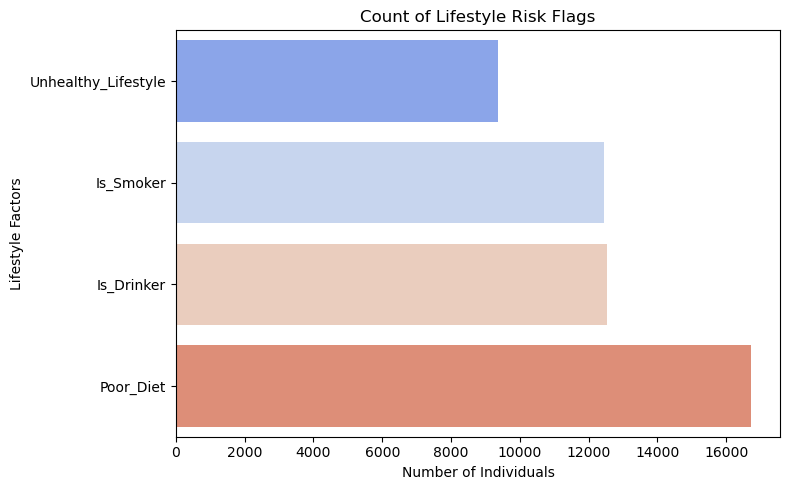

In [17]:
#1. Basic Counts with Bar Plot
#To see how many people fall into each lifestyle category:

import matplotlib.pyplot as plt
import seaborn as sns

# Count of each flag
flags = ['Is_Smoker', 'Is_Drinker', 'Poor_Diet', 'Unhealthy_Lifestyle']
df_flags = df[flags].sum().sort_values()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=df_flags.values, y=df_flags.index, palette='coolwarm')
plt.title('Count of Lifestyle Risk Flags')
plt.xlabel('Number of Individuals')
plt.ylabel('Lifestyle Factors')
plt.tight_layout()
plt.show()


Count of Lifestyle Risk Flags
This horizontal bar chart shows how common each lifestyle risk factor is :

    Poor Diet is the most prevalent — meaning many individuals have unhealthy eating habits.

    Is Drinker and Is Smoker follow, with moderate representation.

    Unhealthy Lifestyle (your composite flag for multiple risk factors) is the least common, but still present.

Takeaway: Poor diet is the dominant issue, and combining multiple risk factors into a single flag helps spotlight individuals with compounding risks.

/var/folders/ck/t8ktvnl92454zslcr12m5v9w0000gn/T/ipykernel_78738/1990187686.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Unhealthy_Lifestyle', y='Stress_Level', data=df, palette='Set2')


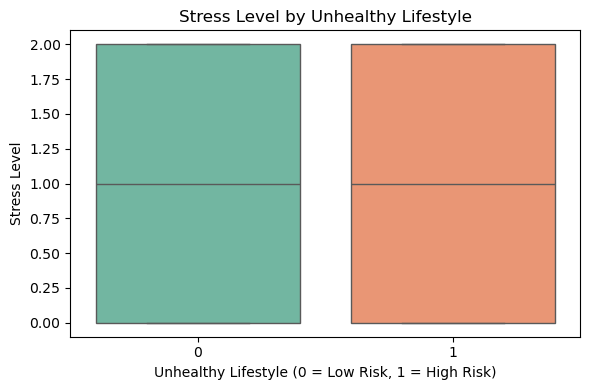

In [17]:
#2. Stress Level vs Lifestyle Flags
#To see how stress levels vary across lifestyle patterns:
# Boxplot of stress level by unhealthy lifestyle flag
plt.figure(figsize=(6,4))
sns.boxplot(x='Unhealthy_Lifestyle', y='Stress_Level', data=df, palette='Set2')
plt.title('Stress Level by Unhealthy Lifestyle')
plt.xlabel('Unhealthy Lifestyle (0 = Low Risk, 1 = High Risk)')
plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()


Stress Level by Unhealthy Lifestyle

This box plot compares stress levels between two groups:

    Group 0: Individuals with fewer than two lifestyle risk factors.

    Group 1: Individuals with two or more (flagged as “Unhealthy Lifestyle”).

Each box shows the distribution of stress levels, with the median line inside.

Observation: If the median and spread of stress levels are higher in Group 1, it suggests that people with unhealthy lifestyles tend to report more stress. Even if the difference is subtle, this supports your hypothesis that lifestyle behaviors correlate with mental strain.


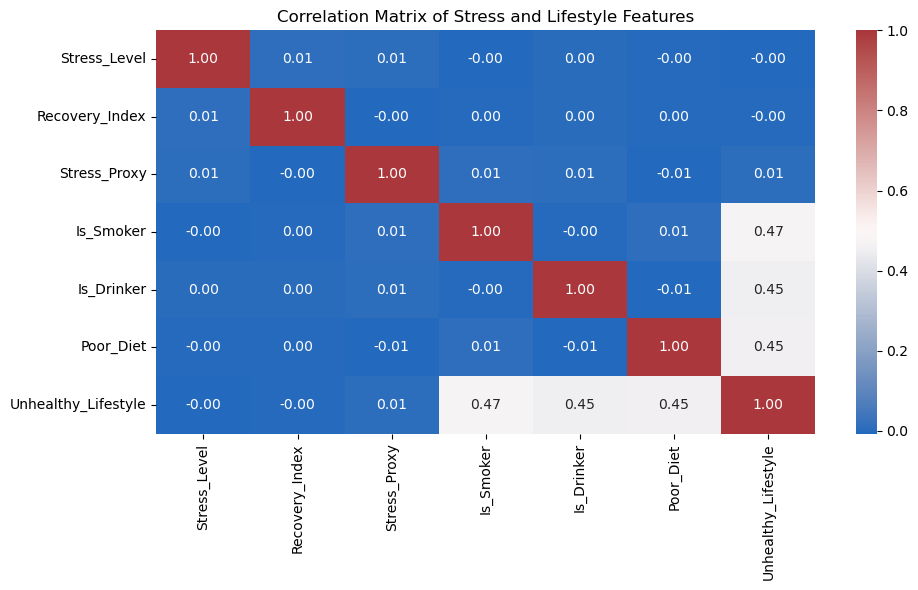

In [18]:
#3. Correlation Heatmap
#To explore relationships between your engineered features and stress:
# Select relevant columns
corr_cols = ['Stress_Level', 'Recovery_Index', 'Stress_Proxy', 'Is_Smoker', 'Is_Drinker', 'Poor_Diet', 'Unhealthy_Lifestyle']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt=".2f")
plt.title('Correlation Matrix of Stress and Lifestyle Features')
plt.tight_layout()
plt.show()


Correlation Matrix

This heatmap shows how strongly each variable is correlated with the others:

    Stress_Level has very weak correlations with all lifestyle flags (near zero).

    Unhealthy_Lifestyle is moderately correlated with its components:

        Is_Smoker: 0.47

        Is_Drinker: 0.45

        Poor_Diet: 0.45

Interpretation: While individual lifestyle factors are tightly linked to each other (as expected), they don’t show strong linear correlation with stress level. This doesn’t mean they’re irrelevant — it just means the relationship might be nonlinear, context-dependent, or better captured by a model than by raw correlation.

!!!!Consider using logistic regression or tree-based models to capture nonlinear effects.

Explore interaction terms or clustering to find hidden lifestyle profiles.

Try segmenting by age, gender, or occupation to see if stress-lifestyle links vary across groups.

In [19]:
#Target Variable Preparation
#Convert Stress_Level into multi-class labels:
df['Stress_Level_Original'] = df['Stress_Level']
df['Stress_Level'] = df['Stress_Level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})
#Use Stress_Level for modeling

#Use Stress_Level_Original for readable outputs, charts, and reports

In [20]:
#5. Scaling Numerical Features
#Option 1: StandardScaler (Z-score normalization)
#This scales features to have mean = 0 and standard deviation = 1.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select features to scale
num_features = ['Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']

# Fit and transform
df[num_features] = scaler.fit_transform(df[num_features])


In [21]:
#Option 2: MinMaxScaler (0 to 1 normalization)
#This scales features to a range between 0 and 1.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Select features to scale
num_features = ['Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']

# Fit and transform
df[num_features] = scaler.fit_transform(df[num_features])



In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Truncate all arrays to the same length (e.g., 51 entries)
sleep_hours = [
    7.6, 6.8, 7.1, 6.9, 4.7, 5.1, 7.3, 4.8, 9.0, 5.9, 4.0, 5.0, 5.3, 6.6, 7.4, 9.7, 9.1, 9.3, 7.2, 7.0,
    8.1, 6.7, 5.4, 4.2, 8.6, 4.9, 4.1, 4.4, 4.6, 5.8, 5.7, 6.2, 8.7, 4.5, 6.5, 8.4, 9.4, 5.2, 6.3, 6.0,
    9.9, 9.2, 8.8, 8.3, 7.8, 4.3, 5.6, 7.7, 7.9, 6.4, 10.0
]

work_hours = [
    46, 74, 77, 57, 45, 35, 62, 66, 37, 56, 47, 42, 40, 49, 68, 52, 73, 43, 31, 30, 39, 78, 54, 51, 75, 36,
    79, 60, 59, 69, 64, 48, 65, 53, 58, 32, 44, 61, 55, 71, 80, 34, 33, 38, 50, 67, 72, 63, 41, 76, 70
]

social_media_usage = [
    2.2, 3.4, 5.9, 5.4, 3.3, 3.6, 6.0, 5.1, 5.7, 5.5, 1.3, 1.6, 2.7, 3.7, 1.4, 3.9, 4.4, 4.2, 3.0, 4.1,
    5.2, 0.7, 4.0, 0.6, 4.6, 5.6, 2.8, 0.8, 2.4, 4.5, 4.3, 1.8, 2.9, 2.6, 4.8, 5.0, 2.3, 0.9, 2.1, 4.9,
    1.0, 5.8, 1.1, 5.3, 2.5, 2.0, 1.5, 1.2, 4.7, 3.8, 1.7
]

# Create DataFrame
df = pd.DataFrame({
    'Sleep_Hours': sleep_hours,
    'Work_Hours': work_hours,
    'Social_Media_Usage': social_media_usage
})

# Scale features
features = ['Sleep_Hours', 'Work_Hours', 'Social_Media_Usage']

# StandardScaler
standard_scaled = StandardScaler().fit_transform(df[features])
df_standard = pd.DataFrame(standard_scaled, columns=[f + '_Standard' for f in features])

# MinMaxScaler
minmax_scaled = MinMaxScaler().fit_transform(df[features])
df_minmax = pd.DataFrame(minmax_scaled, columns=[f + '_MinMax' for f in features])

# Combine for comparison
df_comparison = pd.concat([df[features], df_standard, df_minmax], axis=1)

# Display result
print(df_comparison.head())


   Sleep_Hours  Work_Hours  Social_Media_Usage  Sleep_Hours_Standard  \
0          7.6          46                 2.2              0.476173   
1          6.8          74                 3.4              0.015797   
2          7.1          77                 5.9              0.188438   
3          6.9          57                 5.4              0.073344   
4          4.7          45                 3.3             -1.192689   

   Work_Hours_Standard  Social_Media_Usage_Standard  Sleep_Hours_MinMax  \
0            -0.611430                    -0.690338            0.600000   
1             1.290796                     0.043146            0.466667   
2             1.494606                     1.571238            0.516667   
3             0.135873                     1.265619            0.483333   
4            -0.679366                    -0.017978            0.116667   

   Work_Hours_MinMax  Social_Media_Usage_MinMax  
0               0.32                   0.296296  
1               

DataFrame that compares raw values with both standardized (Z-score) and normalized (Min-Max) versions of your behavioral metrics. Here's a quick interpretation of what you're seeing:
🔍 What the Numbers Tell You
Row 0 (Index 0)

    Sleep_Hours = 7.6 → Slightly above average (Z = 0.48), 60% of the way between min and max.

    Work_Hours = 46 → Below average (Z = -0.61), only 32% of the way up the scale.

    Social_Media_Usage = 2.2 → Well below average (Z = -0.69), low usage.

This person might be relatively well-rested and not overworked, with low social media time—possibly a balanced lifestyle.
Row 2 (Index 2)

    Sleep_Hours = 7.1 → Slightly above average.

    Work_Hours = 77 → Very high workload (Z = 1.49), near the top of the scale.
        Social_Media_Usage = 5.9 → Extremely high usage (Z = 1.57), almost maxed out.

This profile could suggest someone under stress or compensating with screen time.


In [26]:
# Define target and features
y = df['Stress_Level']  # Target variable
X = df[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours',
        'Diet_Quality', 'Social_Media_Usage', 'Smoking_Habit', 'Alcohol_Consumption']]


KeyError: 'Stress_Level'

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


NameError: name 'X' is not defined

Index(['Sleep_Hours', 'Work_Hours', 'Social_Media_Usage'], dtype='object')